## 1. Data Loading and Initial Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [ ]:
census_data = pd.read_csv(r'/content/W-T2_A24census-7.csv')

print(f"Dataset shape: {census_data.shape}")
census_data.head()

Dataset shape: (9543, 11)


,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
0,1,Scott Forks,Alice,Nicholson-Lowe,52,Head,Married,Female,Microbiologist,NaN,NaN
1,1,Scott Forks,Mitchell,Nicholson-Lowe,59,Husband,Married,Male,Homeopath,NaN,NaN
2,1,Scott Forks,Bernard,Nicholson-Lowe,14,Son,NaN,Male,Student,NaN,NaN
3,1,Scott Forks,Kieran,Nicholson-Lowe,13,Son,NaN,Male,Student,NaN,NaN
4,2,Scott Forks,Amy,Nicholls,41,Head,Married,Female,Publishing copy,NaN,Christian


In [ ]:
missing_values = census_data.isnull().sum()
missing_values[missing_values > 0]

,0
Relationship to Head of House,714
Marital Status,2193
Infirmity,9465
Religion,5428


In [ ]:
census_data.dtypes

,0
House Number,object
Street,object
First Name,object
Surname,object
Age,object
Relationship to Head of House,object
Marital Status,object
Gender,object
Occupation,object
Infirmity,object


## 2. Data Cleaning and Preprocessing

In [ ]:
clean_census = census_data.copy()

In [ ]:
non_numeric_houses = clean_census[pd.to_numeric(clean_census['House Number'], errors='coerce').isna()]
print("Non-numeric house numbers:")
print(non_numeric_houses['House Number'].unique())

Non-numeric house numbers:
['Two']


In [ ]:
number_mapping = {'One': '1', 'Two': '2', 'Three': '3', 'Four': '4', 'Five': '5',
                 'Six': '6', 'Seven': '7', 'Eight': '8', 'Nine': '9', 'Ten': '10'}

def standardize_house_number(value):
    if isinstance(value, str) and value.title() in number_mapping:
        return number_mapping[value.title()]
    return value

clean_census['House Number'] = clean_census['House Number'].apply(standardize_house_number)

clean_census['House Number'] = pd.to_numeric(clean_census['House Number'], errors='coerce')

print(f"NaN values in House Number: {clean_census['House Number'].isna().sum()}")

NaN values in House Number: 0


In [ ]:
def standardize_gender(gender):
    if pd.isna(gender):
        return gender
    gender_str = str(gender).strip().lower()
    if gender_str in ['male', 'm']:
        return 'Male'
    elif gender_str in ['female', 'f']:
        return 'Female'
    else:
        return gender

clean_census['Gender'] = clean_census['Gender'].apply(standardize_gender)
print("Unique gender values after standardization:")
print(clean_census['Gender'].unique())

Unique gender values after standardization:
['Female' 'Male' ' ']


In [ ]:
def standardize_marital_status(status):
    if pd.isna(status):
        return 'NA'

    status_str = str(status).strip()
    status_mapping = {
        'S': 'Single',
        'M': 'Married',
        'D': 'Divorced',
        'W': 'Widowed',
        'NA': 'NA',
        'N/A': 'NA',
        's': 'Single',
        'm': 'Married',
        'd': 'Divorced',
        'w': 'Widowed'
    }

    if status_str in status_mapping:
        return status_mapping[status_str]

    return status_str

clean_census['Marital Status'] = clean_census['Marital Status'].apply(standardize_marital_status)
print("Unique marital status values after standardization:")
print(clean_census['Marital Status'].unique())

Unique marital status values after standardization:
['Married' 'NA' 'Widowed' 'Single' 'Divorced']


In [ ]:
clean_census['Age'] = pd.to_numeric(clean_census['Age'], errors='coerce')

print(f"Missing ages: {clean_census['Age'].isna().sum()}")

Missing ages: 2


In [ ]:
clean_census.loc[clean_census['Age'] < 18, 'Marital Status'] = 'NA'

under_18_marital = clean_census[clean_census['Age'] < 18]['Marital Status'].value_counts()
print("Marital status for individuals under 18:")
print(under_18_marital)

Marital status for individuals under 18:
Marital Status
NA    2194
Name: count, dtype: int64


In [ ]:
clean_census.loc[clean_census['Age'] < 5, 'Occupation'] = 'Child'
clean_census.loc[(clean_census['Age'] >= 5) & (clean_census['Age'] < 18), 'Occupation'] = 'Student'

print("Occupations for minors after standardization:")
print(clean_census[clean_census['Age'] < 18]['Occupation'].value_counts())

Occupations for minors after standardization:
Occupation
Student    1678
Child       516
Name: count, dtype: int64


In [ ]:
clean_census['Household'] = clean_census['Street'] + '_' + clean_census['House Number'].astype(str)

minors_missing_religion = clean_census[(clean_census['Age'] < 18) &
                                      ((clean_census['Religion'].isna()) |
                                       (clean_census['Religion'] == 'NA'))]

def get_household_religion(household_id):
    adults = clean_census[(clean_census['Household'] == household_id) &
                         (clean_census['Age'] >= 18)]

    religions = adults['Religion'].dropna().tolist()
    religions = [r for r in religions if r not in ['None', 'NA']]

    if religions:
        return Counter(religions).most_common(1)[0][0]
    return None

imputed_count = 0
for idx, minor in minors_missing_religion.iterrows():
    household_religion = get_household_religion(minor['Household'])
    if household_religion:
        clean_census.loc[idx, 'Religion'] = household_religion
        imputed_count += 1

print(f"Imputed religion for {imputed_count} minors based on household adults")

clean_census.drop('Household', axis=1, inplace=True)

Imputed religion for 1481 minors based on household adults


In [ ]:
missing_values_after = clean_census.isnull().sum()
print("Missing values after cleaning:")
print(missing_values_after[missing_values_after > 0])

Missing values after cleaning:
Age                                 2
Relationship to Head of House     714
Infirmity                        9465
Religion                         3947
dtype: int64


## 3. Age Distribution Analysis

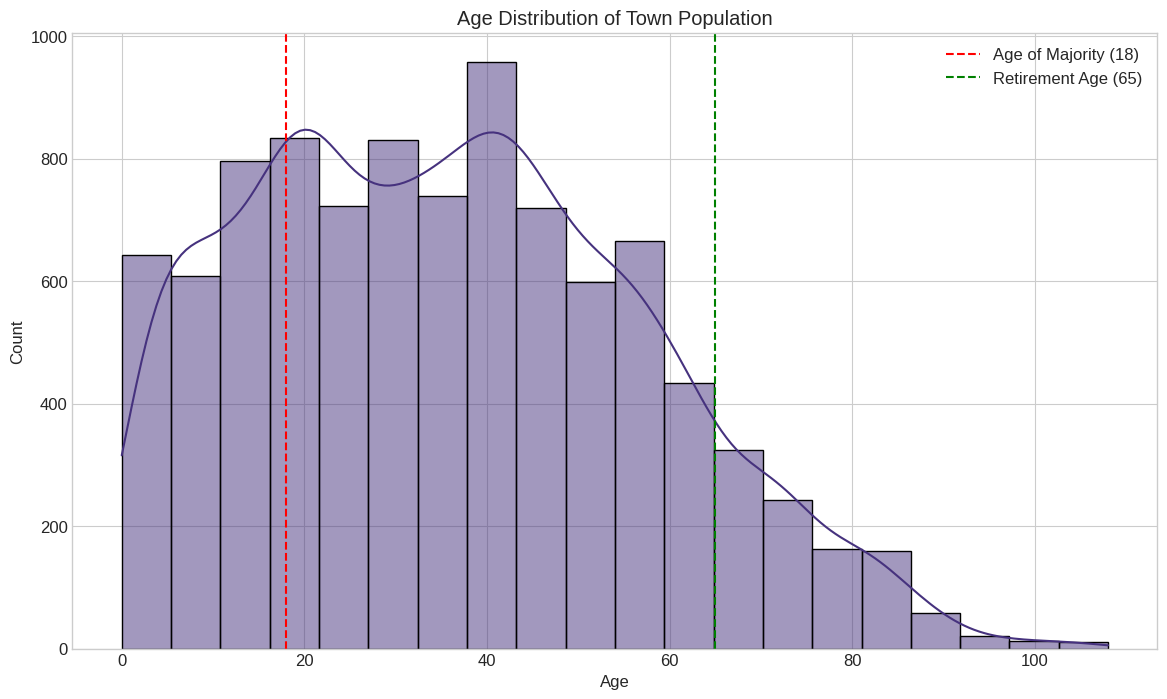

In [ ]:
plt.figure(figsize=(14, 8))
sns.histplot(clean_census['Age'].dropna(), bins=20, kde=True)
plt.axvline(x=18, color='red', linestyle='--', label='Age of Majority (18)')
plt.axvline(x=65, color='green', linestyle='--', label='Retirement Age (65)')
plt.title('Age Distribution of Town Population')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

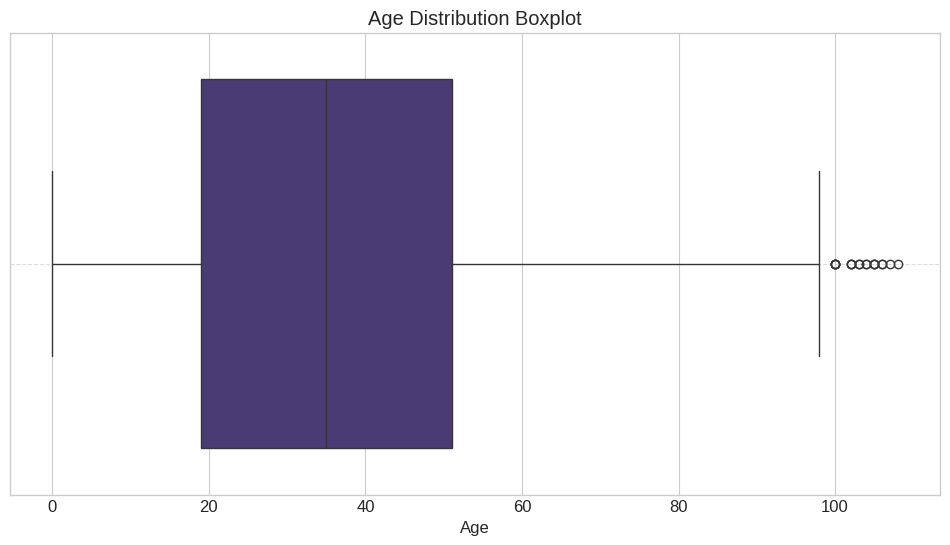

Age Distribution Statistics:
count    9541.000000
mean       35.922975
std        21.527221
min         0.000000
25%        19.000000
50%        35.000000
75%        51.000000
max       108.000000
Name: Age, dtype: float64


In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=clean_census['Age'].dropna())
plt.title('Age Distribution Boxplot')
plt.xlabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

age_stats = clean_census['Age'].describe()
print(f"Age Distribution Statistics:\n{age_stats}")

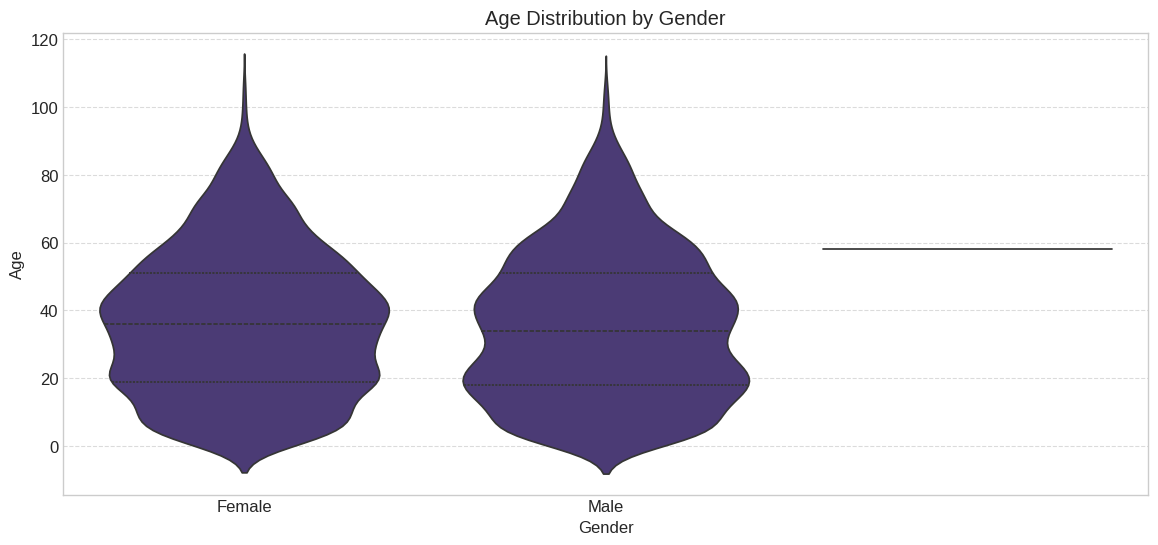

In [ ]:
gender_age = clean_census.dropna(subset=['Age', 'Gender'])
plt.figure(figsize=(14, 6))
sns.violinplot(x='Gender', y='Age', data=gender_age, inner='quartile')
plt.title('Age Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

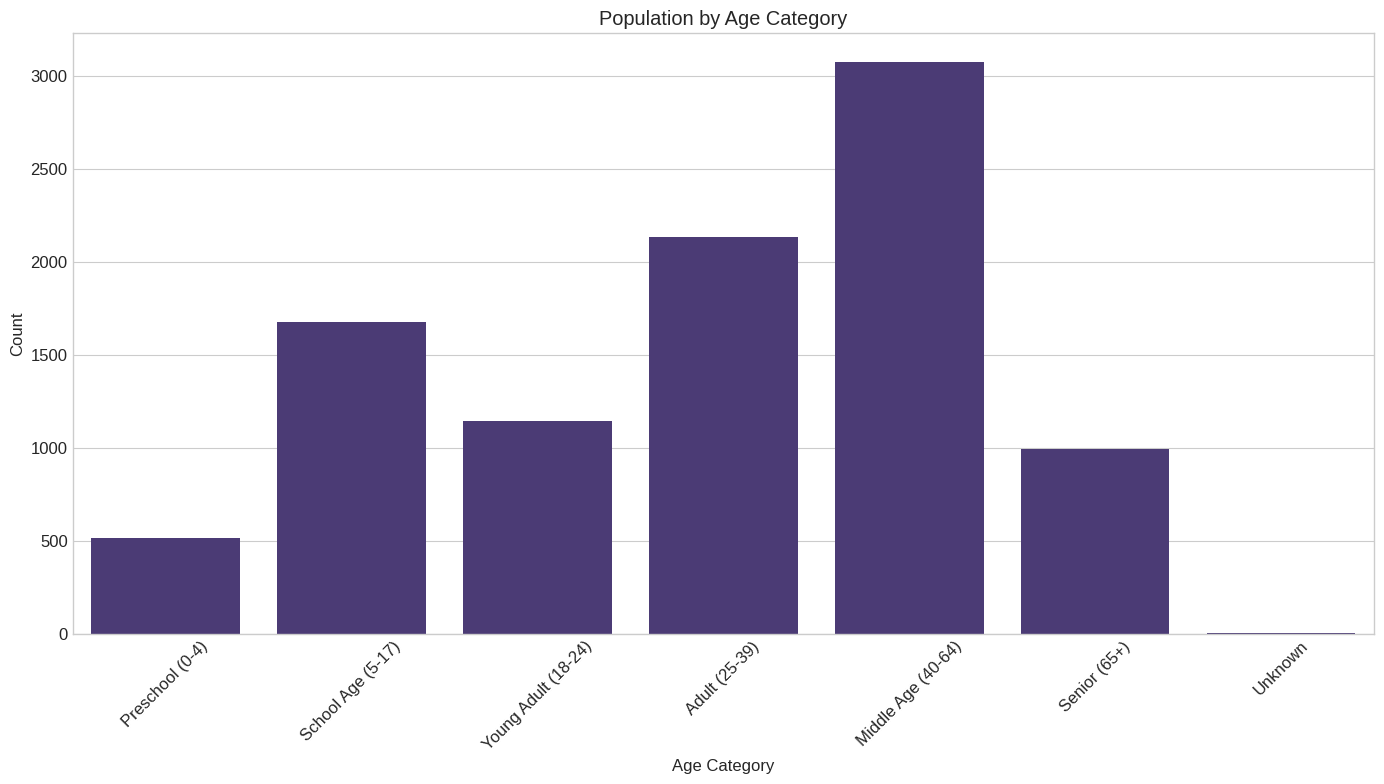

Percentage of population in each age category:
Preschool (0-4): 5.41%
School Age (5-17): 17.58%
Young Adult (18-24): 12.02%
Adult (25-39): 22.35%
Middle Age (40-64): 32.22%
Senior (65+): 10.4%
Unknown: 0.02%


In [ ]:
def categorize_age(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 5:
        return 'Preschool (0-4)'
    elif age < 18:
        return 'School Age (5-17)'
    elif age < 25:
        return 'Young Adult (18-24)'
    elif age < 40:
        return 'Adult (25-39)'
    elif age < 65:
        return 'Middle Age (40-64)'
    else:
        return 'Senior (65+)'

clean_census['Age Category'] = clean_census['Age'].apply(categorize_age)

age_category_order = ['Preschool (0-4)', 'School Age (5-17)', 'Young Adult (18-24)',
                       'Adult (25-39)', 'Middle Age (40-64)', 'Senior (65+)', 'Unknown']

plt.figure(figsize=(14, 8))
age_counts = clean_census['Age Category'].value_counts().reindex(age_category_order)
sns.barplot(x=age_counts.index, y=age_counts.values)
plt.title('Population by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

age_percentage = (age_counts / len(clean_census) * 100).round(2)
print("Percentage of population in each age category:")
for category, percentage in age_percentage.items():
    print(f"{category}: {percentage}%")

In [ ]:
age_bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 100]
age_labels = ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44',
              '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89', '90+']

<ipython-input-20-b3c0991f1ee4>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  male_counts = clean_census[clean_census['Gender'] == 'Male'].groupby('Age Group').size()
<ipython-input-20-b3c0991f1ee4>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  female_counts = clean_census[clean_census['Gender'] == 'Female'].groupby('Age Group').size()
<ipython-input-20-b3c0991f1ee4>:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(abs(int(tick))) for tick in ticks])


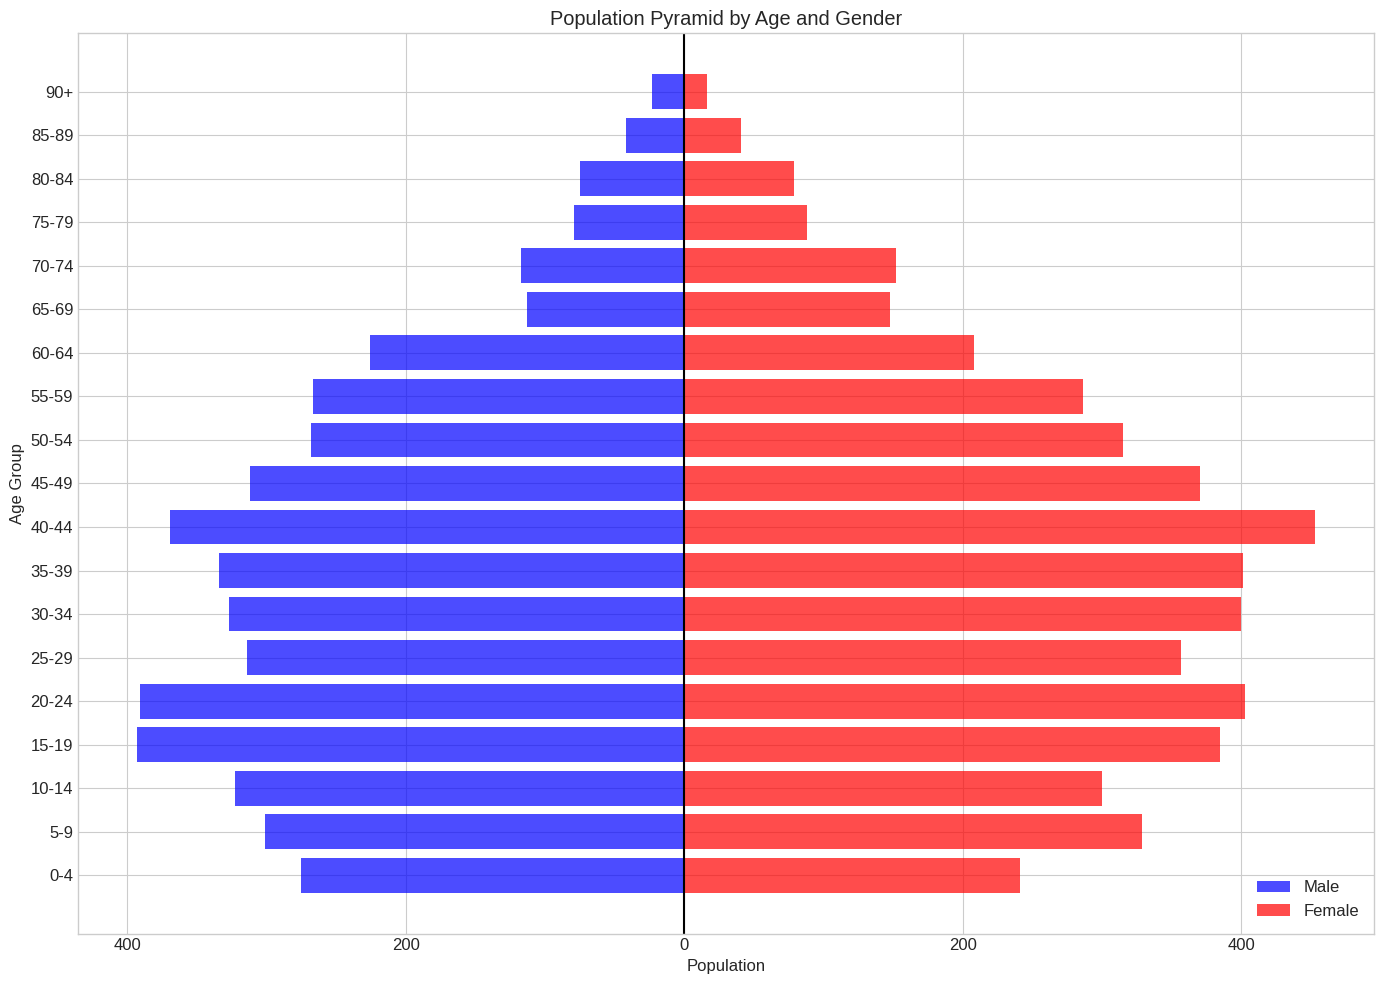

In [ ]:
clean_census['Age Group'] = pd.cut(clean_census['Age'], bins=age_bins, labels=age_labels, right=False)

male_counts = clean_census[clean_census['Gender'] == 'Male'].groupby('Age Group').size()
female_counts = clean_census[clean_census['Gender'] == 'Female'].groupby('Age Group').size()

fig, ax = plt.subplots(figsize=(14, 10))

ax.barh(y=male_counts.index, width=-male_counts, color='blue', alpha=0.7, label='Male')
ax.barh(y=female_counts.index, width=female_counts, color='red', alpha=0.7, label='Female')

ax.set_xlabel('Population')
ax.set_ylabel('Age Group')
ax.set_title('Population Pyramid by Age and Gender')

ax.legend(loc='lower right')

ticks = ax.get_xticks()
ax.set_xticklabels([str(abs(int(tick))) for tick in ticks])

ax.axvline(x=0, color='black', linestyle='-')

plt.tight_layout()
plt.show()

## 4. Religious Distribution Analysis

In [ ]:
religion_counts = clean_census['Religion'].value_counts()
print("Religious distribution:")
print(religion_counts)

Religious distribution:
Religion
Christian      2860
Catholic       1476
Methodist       940
Muslim          168
Sikh             81
Jewish           52
Agnostic          8
Nope              4
Undecided         2
Orthodoxy         2
Jedi              1
Pagan             1
Housekeeper       1
Name: count, dtype: int64


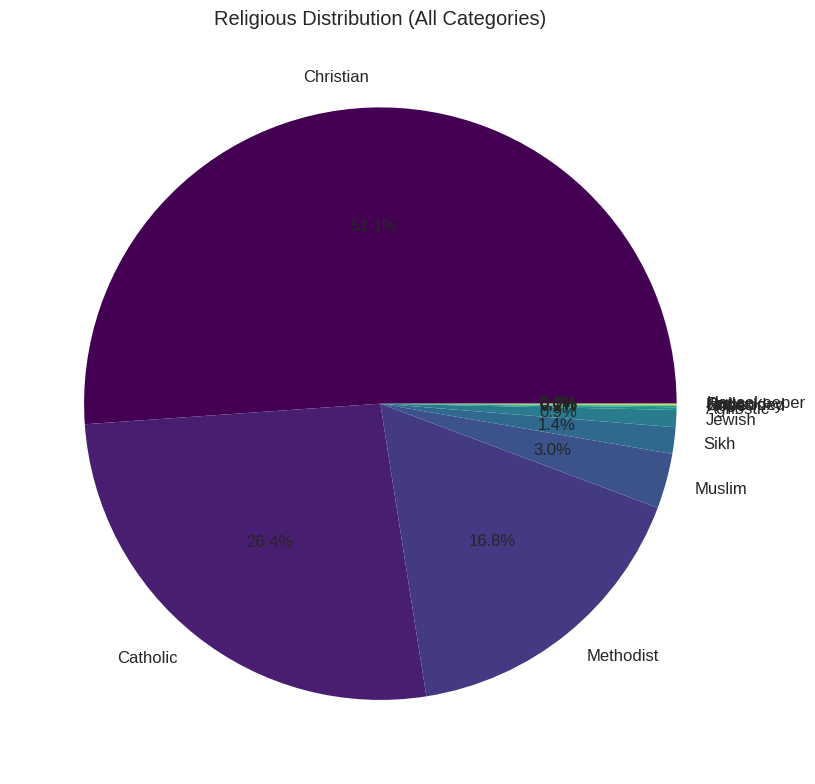

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
religion_counts.plot(kind='pie', autopct='%1.1f%%', ax=ax, cmap='viridis')
plt.title('Religious Distribution (All Categories)')
plt.ylabel('')
plt.tight_layout()
plt.show()

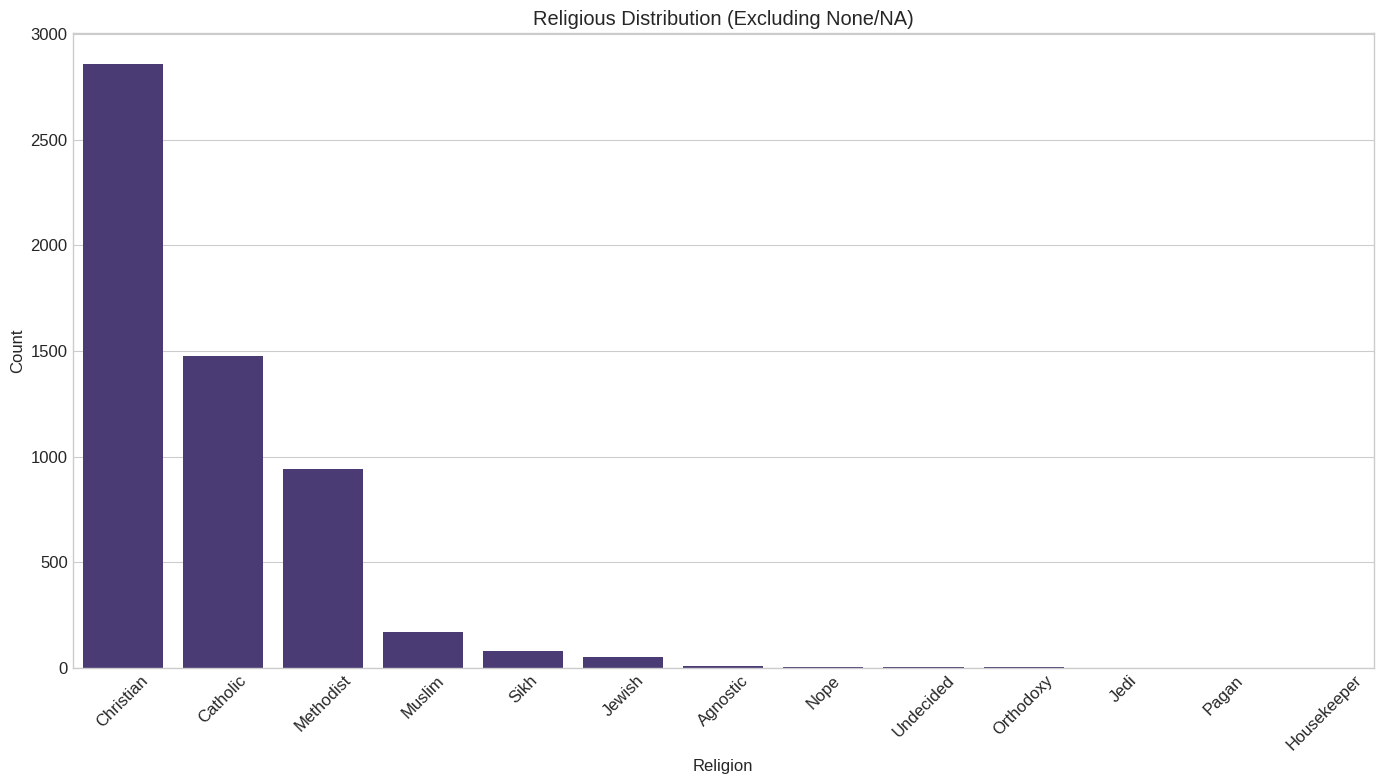

Percentage of town population by religion:
Christian: 29.97%
Catholic: 15.47%
Methodist: 9.85%
Muslim: 1.76%
Sikh: 0.85%
Jewish: 0.54%
Agnostic: 0.08%
Nope: 0.04%
Undecided: 0.02%
Orthodoxy: 0.02%
Jedi: 0.01%
Pagan: 0.01%
Housekeeper: 0.01%


In [ ]:
religious_census = clean_census[~clean_census['Religion'].isin(['None', 'NA'])].copy()
religion_counts = religious_census['Religion'].value_counts()

plt.figure(figsize=(14, 8))
sns.barplot(x=religion_counts.index, y=religion_counts.values)
plt.title('Religious Distribution (Excluding None/NA)')
plt.xlabel('Religion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

religion_percentage = (religion_counts / len(clean_census) * 100).round(2)
print("Percentage of town population by religion:")
for religion, percentage in religion_percentage.items():
    print(f"{religion}: {percentage}%")

<Figure size 1500x1000 with 0 Axes>

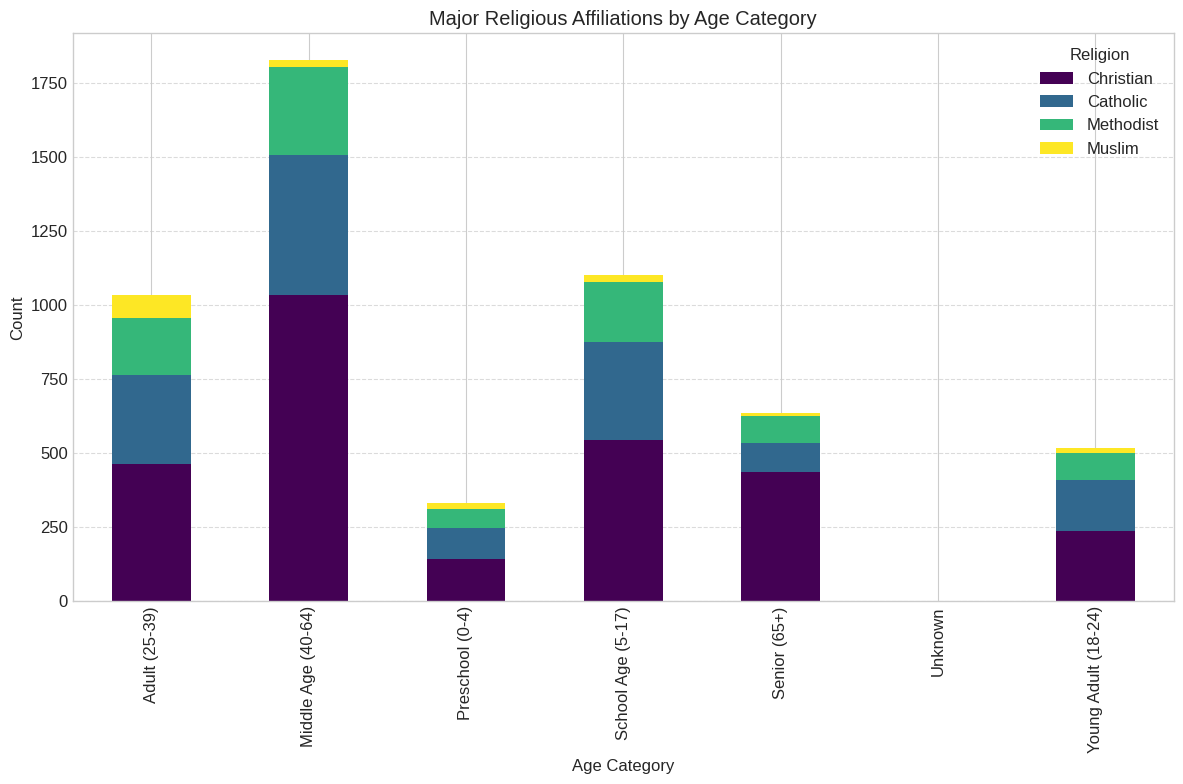

In [ ]:
religious_by_age = pd.crosstab(clean_census['Age Category'], clean_census['Religion'])
religious_by_age_filtered = religious_by_age[['Christian', 'Catholic', 'Methodist', 'Muslim']]

plt.figure(figsize=(15, 10))
religious_by_age_filtered.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Major Religious Affiliations by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Count')
plt.legend(title='Religion')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

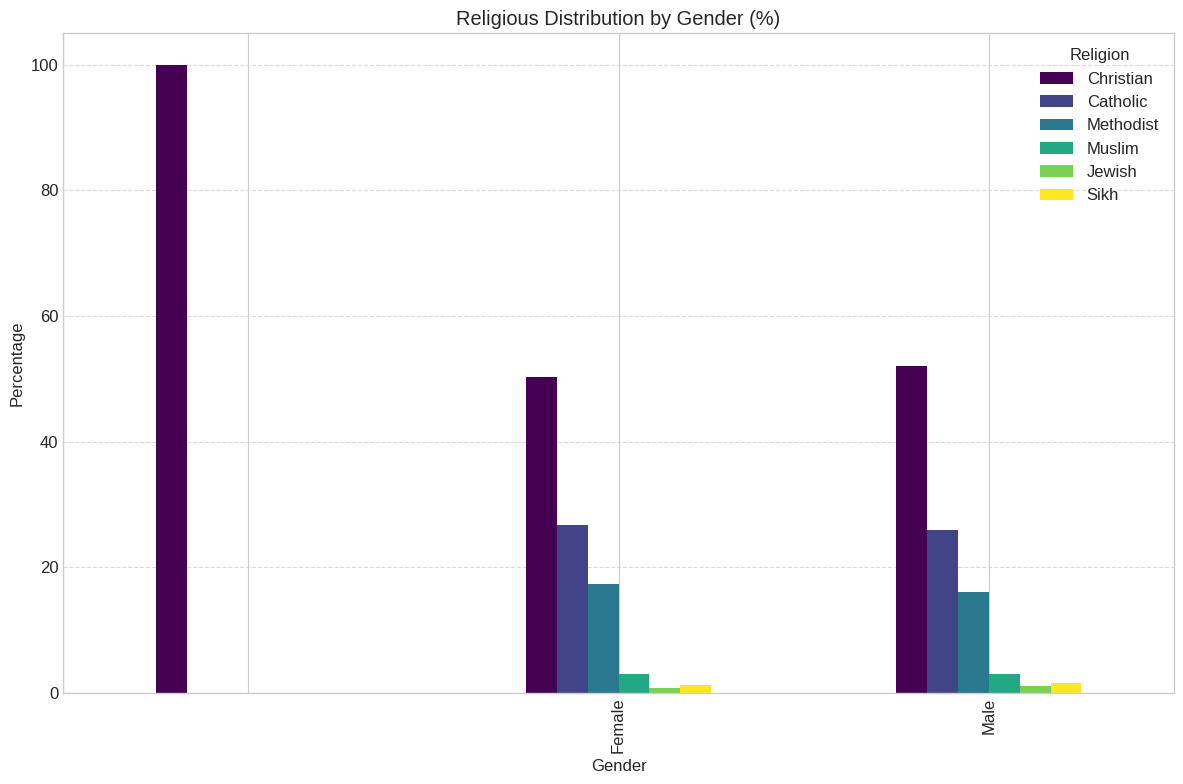

In [ ]:
religion_by_gender = pd.crosstab(clean_census['Gender'], clean_census['Religion'])
religion_by_gender_pct = religion_by_gender.div(religion_by_gender.sum(axis=1), axis=0) * 100

main_religions = ['Christian', 'Catholic', 'Methodist', 'Muslim', 'Jewish', 'Sikh']
filtered_religion_gender = religion_by_gender_pct[main_religions]

plt.figure(figsize=(14, 8))
filtered_religion_gender.plot(kind='bar', colormap='viridis')
plt.title('Religious Distribution by Gender (%)')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.legend(title='Religion')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Housing and Household Analysis

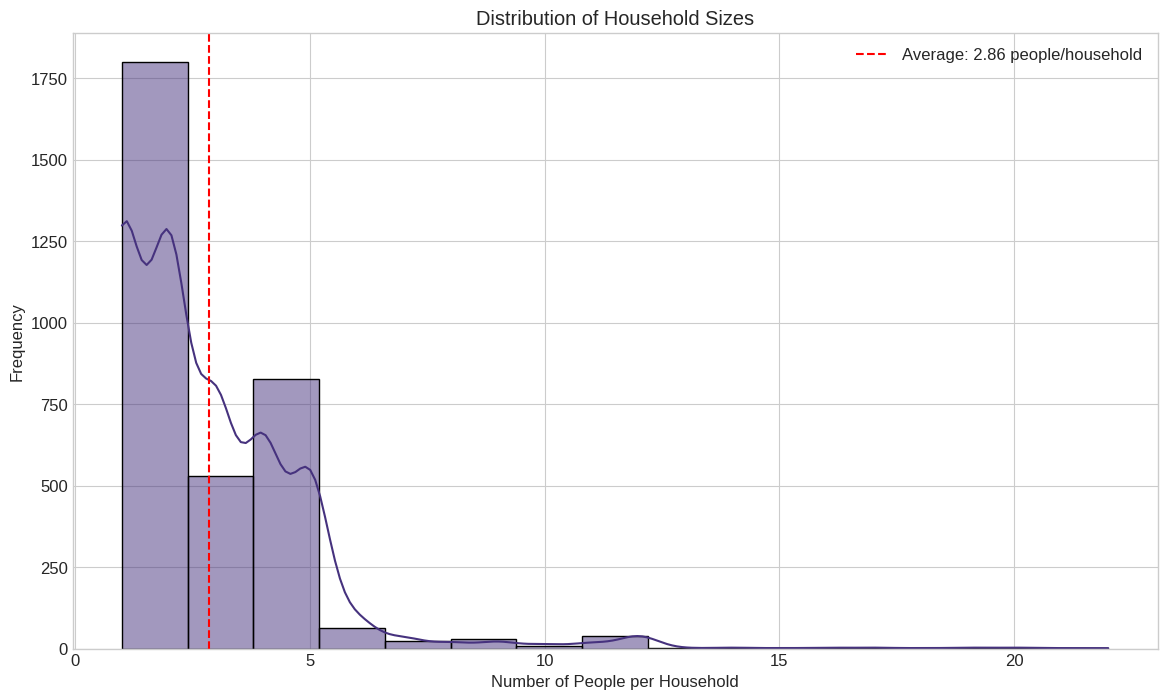

Total households: 3332
Average household size: 2.86 people
Median household size: 2.0 people
Largest household: 22 people
Smallest household: 1 person

Percentage of households by size:
1 person household: 27.67%
2 person household: 26.35%
3 person household: 15.88%
4 person household: 13.3%
5 person household: 11.49%
6 person household: 1.86%
7 person household: 0.69%
8 person household: 0.39%
9 person household: 0.45%
10 person household: 0.27%
11 person household: 0.36%
12 person household: 0.84%
13 person household: 0.03%
14 person household: 0.06%
15 person household: 0.03%
16 person household: 0.06%
17 person household: 0.06%
18 person household: 0.03%
19 person household: 0.06%
20 person household: 0.06%
21 person household: 0.03%
22 person household: 0.03%


In [ ]:
clean_census['Household'] = clean_census['Street'] + '_' + clean_census['House Number'].astype(str)

household_sizes = clean_census.groupby('Household').size()
average_household_size = household_sizes.mean()

plt.figure(figsize=(14, 8))
sns.histplot(household_sizes, bins=15, kde=True)
plt.axvline(x=average_household_size, color='red', linestyle='--',
            label=f'Average: {average_household_size:.2f} people/household')
plt.title('Distribution of Household Sizes')
plt.xlabel('Number of People per Household')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"Total households: {len(household_sizes)}")
print(f"Average household size: {average_household_size:.2f} people")
print(f"Median household size: {household_sizes.median()} people")
print(f"Largest household: {household_sizes.max()} people")
print(f"Smallest household: {household_sizes.min()} person")

household_size_pct = (household_sizes.value_counts().sort_index() / len(household_sizes) * 100).round(2)
print("\nPercentage of households by size:")
for size, pct in household_size_pct.items():
    print(f"{size} person household: {pct}%")

<ipython-input-27-1f0b2b3f1564>:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  household_types = clean_census.groupby('Household').apply(categorize_household)


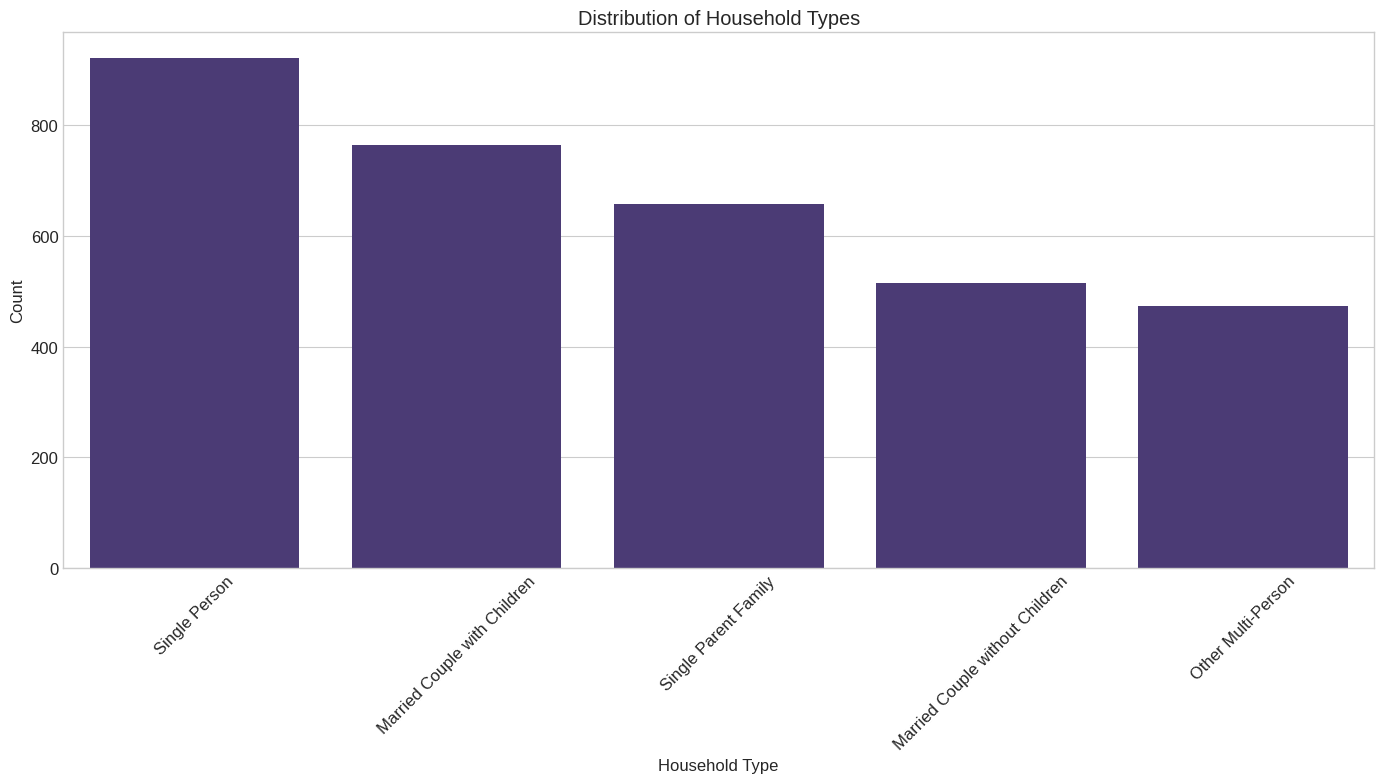

Percentage of households by type:
Single Person: 27.67%
Married Couple with Children: 22.93%
Single Parent Family: 19.75%
Married Couple without Children: 15.46%
Other Multi-Person: 14.2%


In [ ]:
def categorize_household(household_df):
    size = len(household_df)

    if size == 1:
        return 'Single Person'

    has_husband = 'Husband' in household_df['Relationship to Head of House'].values
    has_wife = 'Wife' in household_df['Relationship to Head of House'].values
    has_children = any(rel in ['Son', 'Daughter', 'Child'] for rel in household_df['Relationship to Head of House'].values)

    if has_husband or has_wife:
        if has_children:
            return 'Married Couple with Children'
        else:
            return 'Married Couple without Children'

    if has_children:
        return 'Single Parent Family'

    return 'Other Multi-Person'

household_types = clean_census.groupby('Household').apply(categorize_household)
household_type_counts = household_types.value_counts()

plt.figure(figsize=(14, 8))
sns.barplot(x=household_type_counts.index, y=household_type_counts.values)
plt.title('Distribution of Household Types')
plt.xlabel('Household Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

household_type_pct = (household_type_counts / len(household_types) * 100).round(2)
print("Percentage of households by type:")
for htype, pct in household_type_pct.items():
    print(f"{htype}: {pct}%")

## 6. Occupation and Employment Analysis

In [ ]:
adult_census = clean_census[clean_census['Age'] >= 18].copy()
adult_occupations = adult_census['Occupation'].value_counts()

print("Top 20 occupations among adults:")
print(adult_occupations.head(20))

Top 20 occupations among adults:
Occupation
University Student                    672
Unemployed                            586
Student                               118
Licensed conveyancer                   19
Electrical engineer                    18
Psychologist, occupational             17
Petroleum engineer                     17
Clinical cytogeneticist                17
Engineer, chemical                     17
Logistics and distribution manager     17
Field trials officer                   16
Production engineer                    16
PhD Student                            16
Social researcher                      15
Planning and development surveyor      15
Tourism officer                        15
Designer, industrial/product           15
Volunteer coordinator                  15
Early years teacher                    15
Charity officer                        15
Name: count, dtype: int64


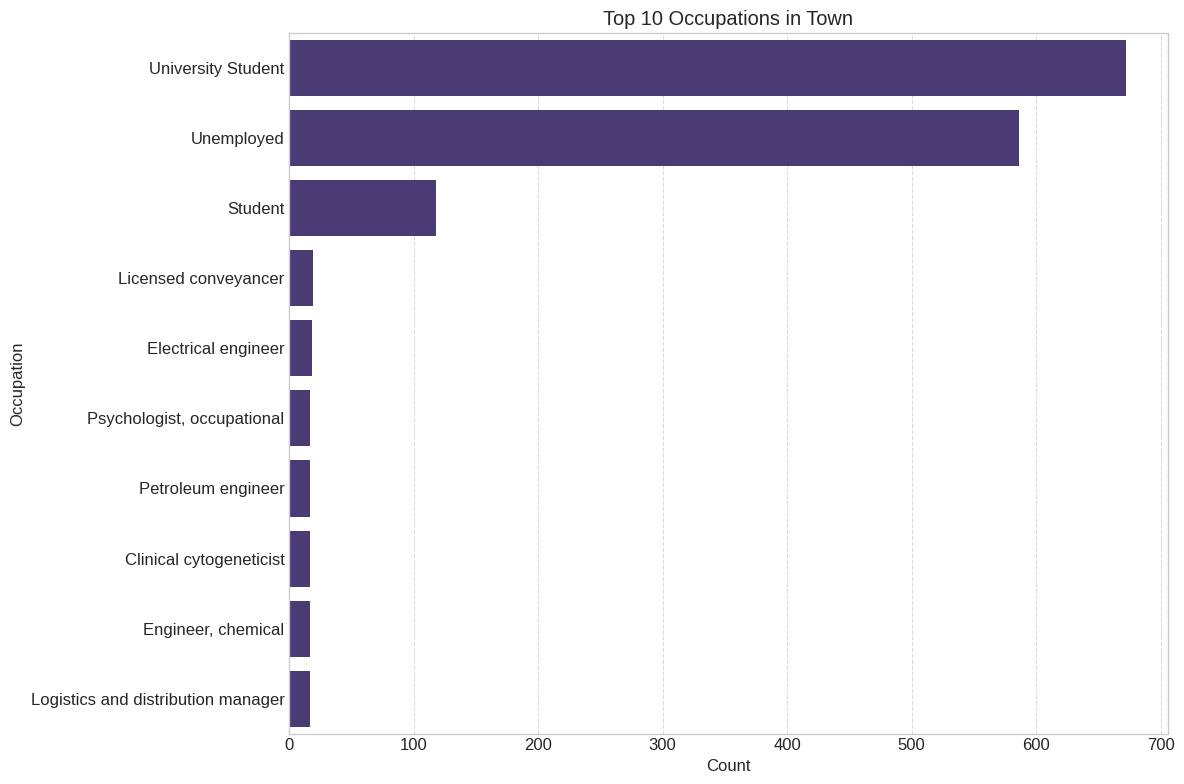

In [ ]:
top_occupations = adult_occupations.head(10)
plt.figure(figsize=(12, 8))
sns.barplot(x=top_occupations.values, y=top_occupations.index)
plt.title('Top 10 Occupations in Town')
plt.xlabel('Count')
plt.ylabel('Occupation')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

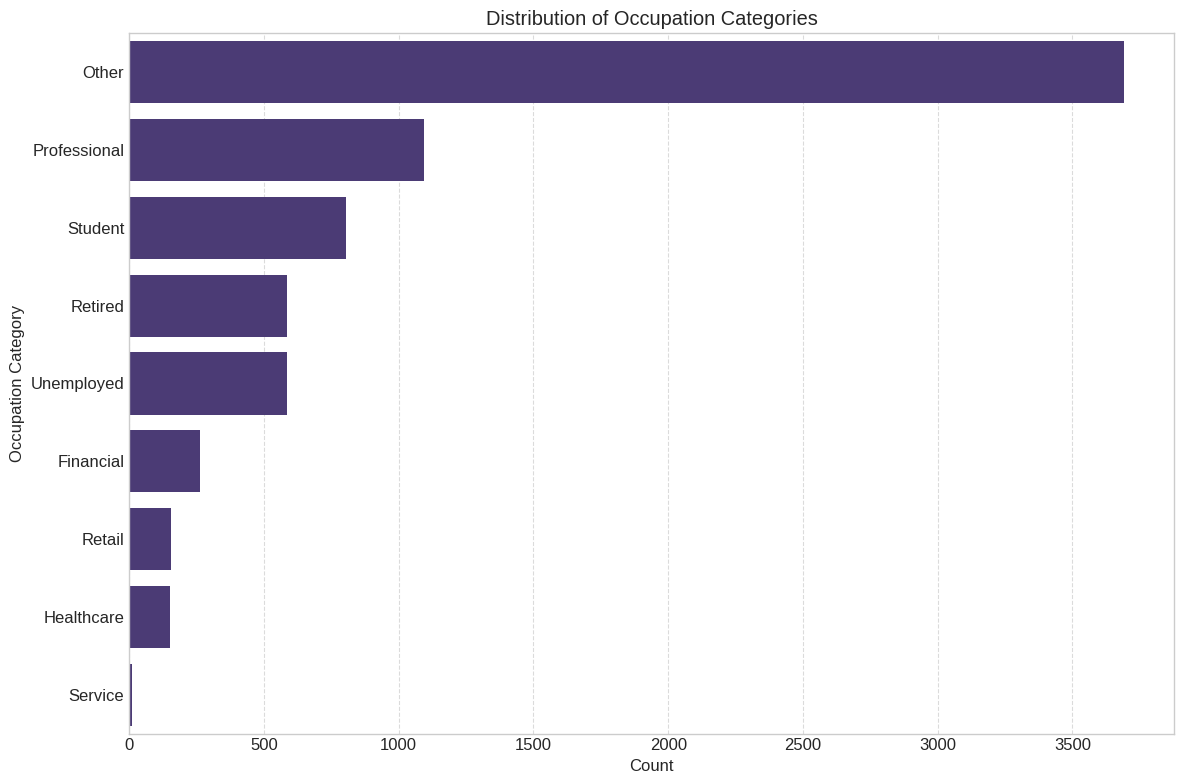

Percentage of adults in each occupation category:
Other: 50.25%
Professional: 14.9%
Student: 10.97%
Retired: 7.99%
Unemployed: 7.98%
Financial: 3.58%
Retail: 2.14%
Healthcare: 2.07%
Service: 0.12%


In [ ]:
occupation_categories = {
    'Professional': ['Doctor', 'Lawyer', 'Engineer', 'Architect', 'Teacher', 'Professor', 'Scientist'],
    'Financial': ['Banker', 'Accountant', 'Financial', 'Insurance', 'Investment'],
    'Service': ['Waiter', 'Waitress', 'Barista', 'Bartender', 'Chef', 'Cook', 'Cleaner', 'Maid'],
    'Trade': ['Carpenter', 'Plumber', 'Electrician', 'Mechanic', 'Builder', 'Painter'],
    'Healthcare': ['Nurse', 'Doctor', 'Dentist', 'Pharmacist', 'Surgeon', 'Physician'],
    'Student': ['Student', 'University Student'],
    'Retail': ['Retail', 'Shop', 'Sales', 'Cashier', 'Assistant'],
    'Unemployed': ['Unemployed'],
    'Retired': ['Retired'],
    'Other': []
}

def categorize_occupation(occupation):
    if pd.isna(occupation):
        return 'Other'

    occupation_str = str(occupation).lower()

    for category, keywords in occupation_categories.items():
        if any(keyword.lower() in occupation_str for keyword in keywords):
            return category
    return 'Other'

adult_census['Occupation Category'] = adult_census['Occupation'].apply(categorize_occupation)
occupation_category_counts = adult_census['Occupation Category'].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(x=occupation_category_counts.values, y=occupation_category_counts.index)
plt.title('Distribution of Occupation Categories')
plt.xlabel('Count')
plt.ylabel('Occupation Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

occupation_category_pct = (occupation_category_counts / len(adult_census) * 100).round(2)
print("Percentage of adults in each occupation category:")
for category, percentage in occupation_category_pct.items():
    print(f"{category}: {percentage}%")

Unemployment rate: 7.98%


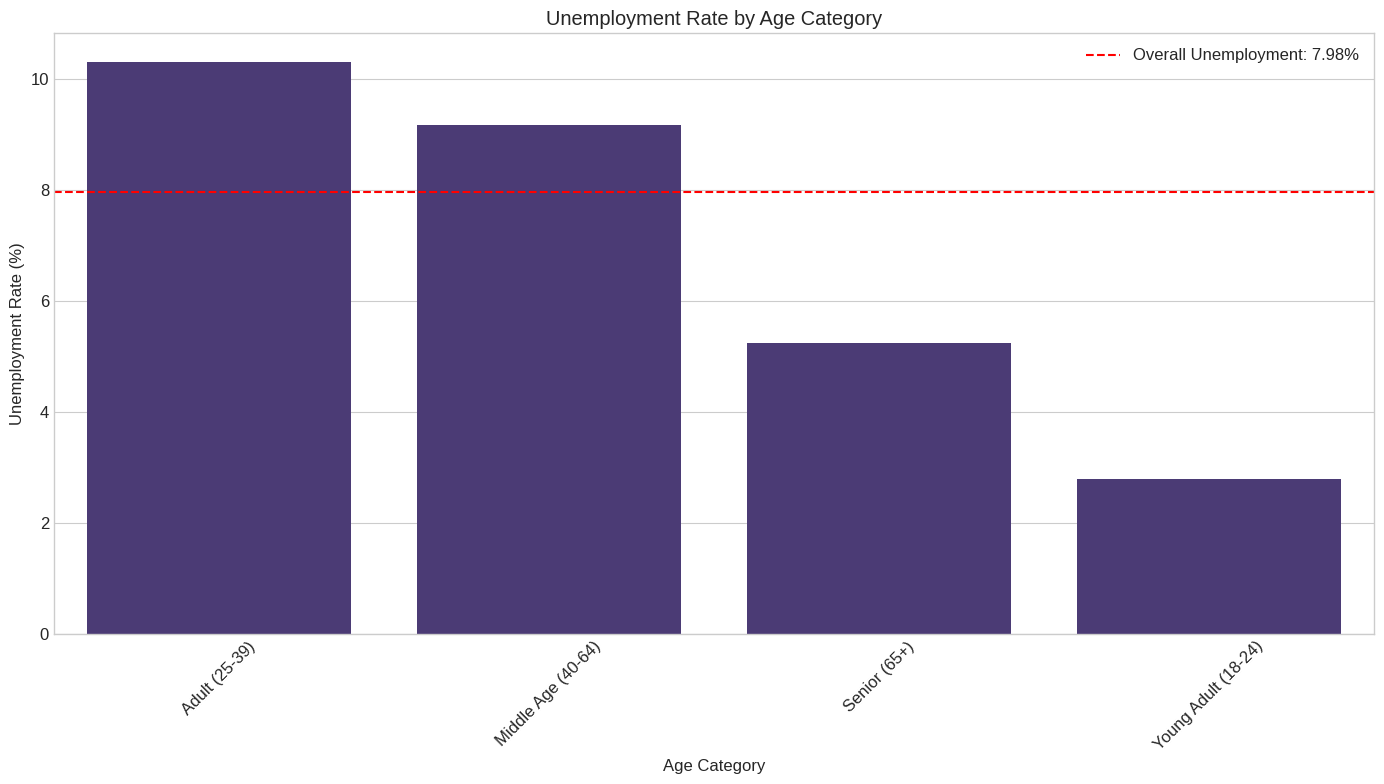

In [ ]:
unemployed_count = len(adult_census[adult_census['Occupation'] == 'Unemployed'])
unemployment_rate = (unemployed_count / len(adult_census)) * 100

print(f"Unemployment rate: {unemployment_rate:.2f}%")

unemployment_by_age = pd.crosstab(adult_census['Age Category'],
                                adult_census['Occupation'] == 'Unemployed',
                                normalize='index') * 100

plt.figure(figsize=(14, 8))
sns.barplot(x=unemployment_by_age.index, y=unemployment_by_age[True])
plt.title('Unemployment Rate by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.axhline(y=unemployment_rate, color='red', linestyle='--',
            label=f'Overall Unemployment: {unemployment_rate:.2f}%')
plt.legend()
plt.tight_layout()
plt.show()

Number of university students (definite commuters): 672
Total potential commuters: 849
Percentage of adult population: 11.56%


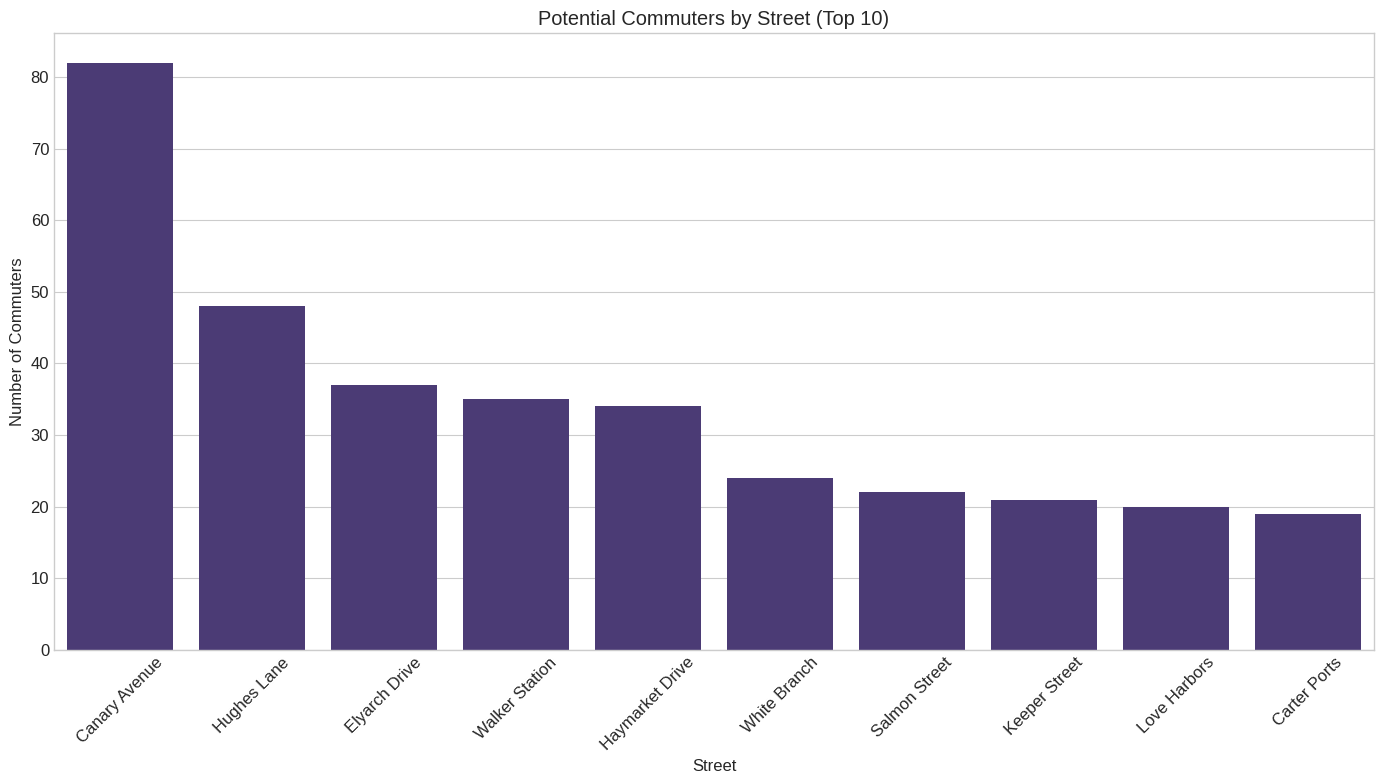

In [ ]:
uni_students = clean_census[clean_census['Occupation'] == 'University Student']
print(f"Number of university students (definite commuters): {len(uni_students)}")

potential_commuter_jobs = ['University Student', 'Banker', 'Financial adviser', 'Investment banker',
                           'Financial planner', 'Lawyer', 'Barrister', 'Doctor', 'Hospital doctor',
                           'Surgeon', 'Chief Financial Officer']

def is_commuter(occupation):
    if pd.isna(occupation):
        return False
    return any(job.lower() in str(occupation).lower() for job in potential_commuter_jobs)

clean_census['Potential Commuter'] = clean_census['Occupation'].apply(is_commuter)

commuter_count = clean_census['Potential Commuter'].sum()
commuter_percentage = (commuter_count / len(adult_census) * 100)

print(f"Total potential commuters: {commuter_count}")
print(f"Percentage of adult population: {commuter_percentage:.2f}%")

commuter_by_street = clean_census[clean_census['Potential Commuter']].groupby('Street').size().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x=commuter_by_street.head(10).index, y=commuter_by_street.head(10).values)
plt.title('Potential Commuters by Street (Top 10)')
plt.xlabel('Street')
plt.ylabel('Number of Commuters')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Health and Infirmity Analysis

Infirmity distribution:
Infirmity
Physical Disability    20
Unknown Infection      18
                       15
Mental Disability       7
Blind                   7
Deaf                    6
Disabled                5
Name: count, dtype: int64


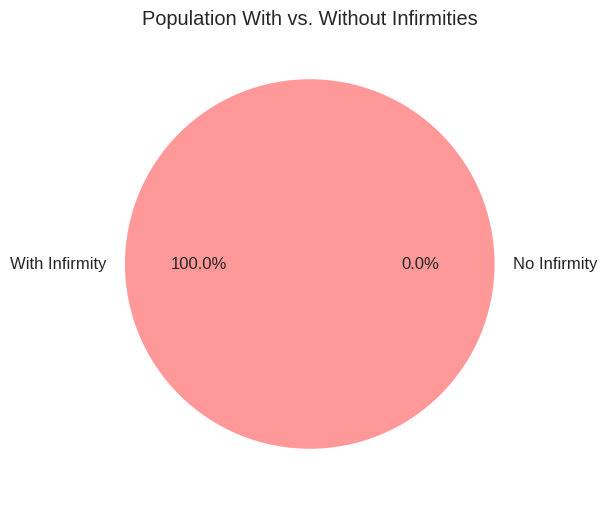

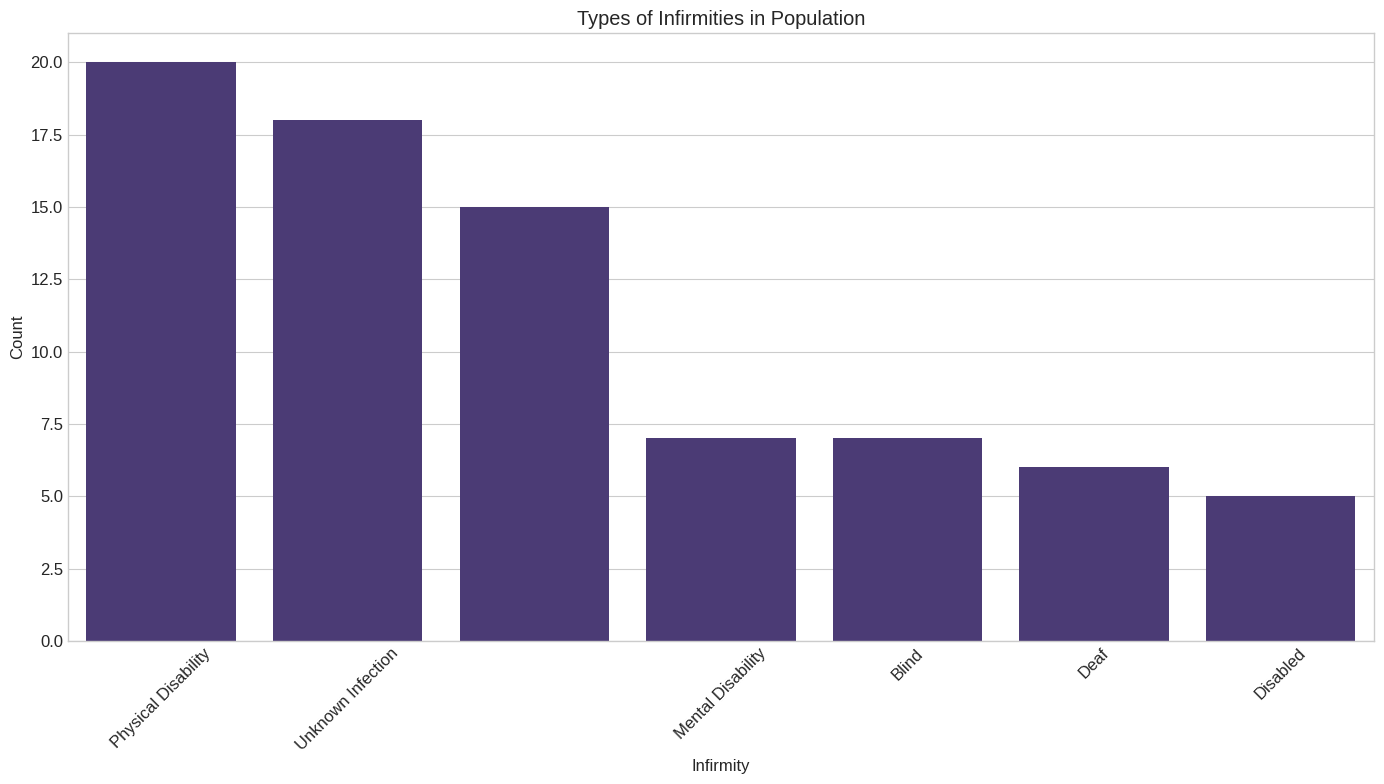


Percentage of population with specific infirmities:
Physical Disability: 0.21%
Unknown Infection: 0.19%
 : 0.16%
Mental Disability: 0.07%
Blind: 0.07%
Deaf: 0.06%
Disabled: 0.05%


In [ ]:
infirmity_counts = clean_census['Infirmity'].value_counts()
print("Infirmity distribution:")
print(infirmity_counts)

plt.figure(figsize=(10, 6))
plt.pie([len(clean_census[clean_census['Infirmity'] != 'None']),
         len(clean_census[clean_census['Infirmity'] == 'None'])],
       labels=['With Infirmity', 'No Infirmity'],
       autopct='%1.1f%%',
       colors=['#ff9999','#66b3ff'])
plt.title('Population With vs. Without Infirmities')
plt.show()

infirmities = clean_census[clean_census['Infirmity'] != 'None']
actual_infirmity_counts = infirmities['Infirmity'].value_counts()

if len(actual_infirmity_counts) > 0:
    plt.figure(figsize=(14, 8))
    sns.barplot(x=actual_infirmity_counts.index, y=actual_infirmity_counts.values)
    plt.title('Types of Infirmities in Population')
    plt.xlabel('Infirmity')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    infirmity_percentage = (actual_infirmity_counts / len(clean_census) * 100).round(2)
    print("\nPercentage of population with specific infirmities:")
    for infirmity, percentage in infirmity_percentage.items():
        print(f"{infirmity}: {percentage}%")
else:
    print("\nNo specific infirmities found in the dataset.")

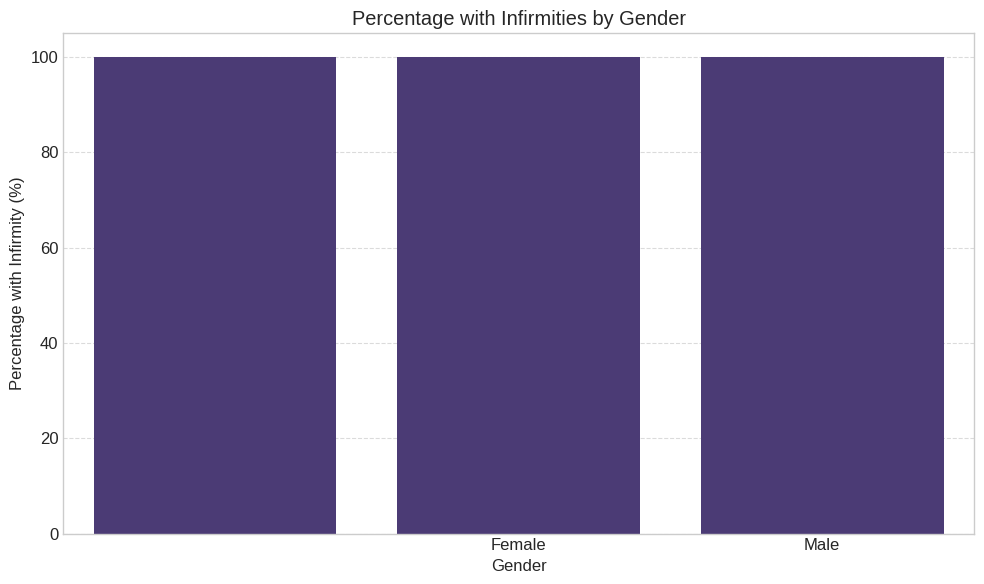

In [ ]:
infirmity_gender = pd.crosstab(clean_census['Gender'], clean_census['Infirmity'] != 'None')
infirmity_gender_pct = infirmity_gender.div(infirmity_gender.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=infirmity_gender_pct.index, y=infirmity_gender_pct[True])
plt.title('Percentage with Infirmities by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage with Infirmity (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

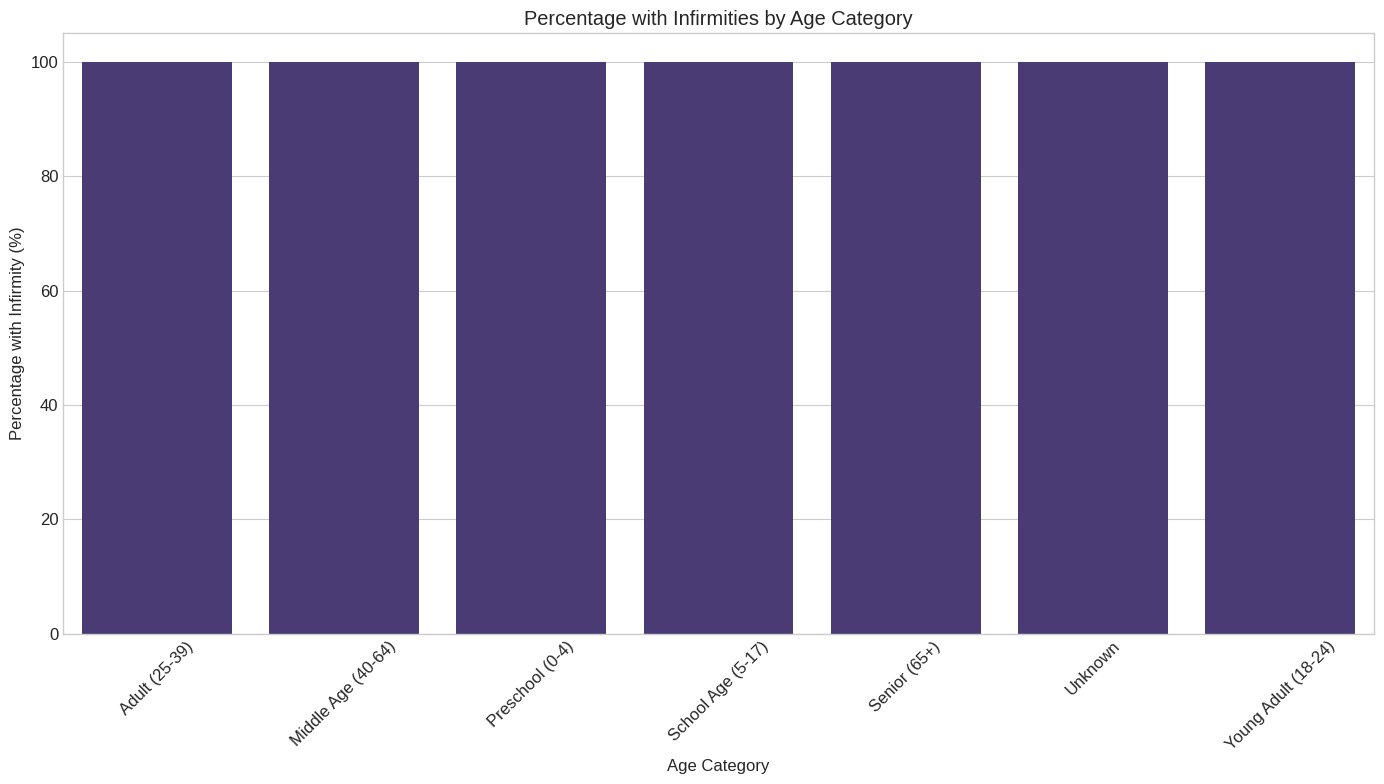

In [ ]:
infirmity_by_age = pd.crosstab(clean_census['Age Category'],
                              clean_census['Infirmity'] != 'None',
                              normalize='index') * 100

plt.figure(figsize=(14, 8))
sns.barplot(x=infirmity_by_age.index, y=infirmity_by_age[True])
plt.title('Percentage with Infirmities by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Percentage with Infirmity (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Population Growth Analysis

In [ ]:
working_age = clean_census[(clean_census['Age'] >= 18) & (clean_census['Age'] < 65)]
children = clean_census[clean_census['Age'] < 18]
elderly = clean_census[clean_census['Age'] >= 65]

working_age_count = len(working_age)
children_count = len(children)
elderly_count = len(elderly)
total_population = len(clean_census)

child_dependency_ratio = (children_count / working_age_count) * 100
elderly_dependency_ratio = (elderly_count / working_age_count) * 100
total_dependency_ratio = ((children_count + elderly_count) / working_age_count) * 100

print("Dependency Ratios:")
print(f"Child Dependency Ratio: {child_dependency_ratio:.2f}%")
print(f"Elderly Dependency Ratio: {elderly_dependency_ratio:.2f}%")
print(f"Total Dependency Ratio: {total_dependency_ratio:.2f}%")

Dependency Ratios:
Child Dependency Ratio: 34.52%
Elderly Dependency Ratio: 15.61%
Total Dependency Ratio: 50.13%


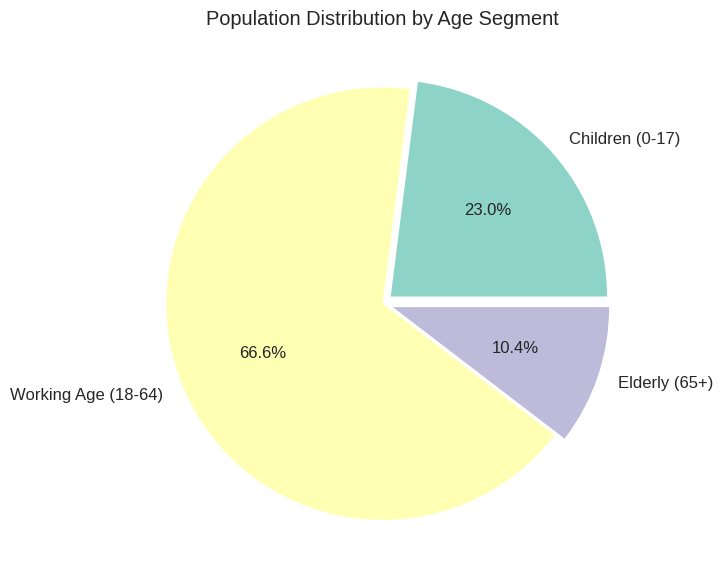

<ipython-input-37-0f738a17b28f>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Dependency Type', y='Ratio', data=dependency_data, palette='viridis')


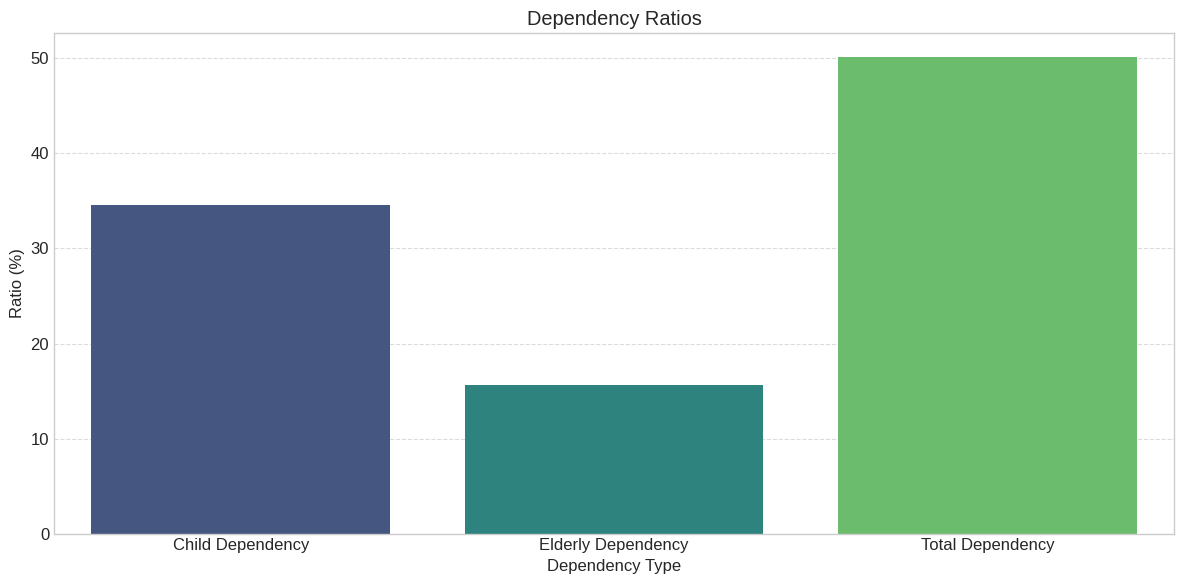

In [ ]:
population_segments = [children_count, working_age_count, elderly_count]
segment_labels = ['Children (0-17)', 'Working Age (18-64)', 'Elderly (65+)']
segment_colors = ['#8dd3c7', '#ffffb3', '#bebada']

plt.figure(figsize=(10, 6))
plt.pie(population_segments, labels=segment_labels, autopct='%1.1f%%', colors=segment_colors, explode=[0.05, 0, 0.05])
plt.title('Population Distribution by Age Segment')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
dependency_data = pd.DataFrame({
    'Dependency Type': ['Child Dependency', 'Elderly Dependency', 'Total Dependency'],
    'Ratio': [child_dependency_ratio, elderly_dependency_ratio, total_dependency_ratio]
})
sns.barplot(x='Dependency Type', y='Ratio', data=dependency_data, palette='viridis')
plt.title('Dependency Ratios')
plt.ylabel('Ratio (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
under_5 = clean_census[clean_census['Age'] < 5]
under_5_count = len(under_5)

annual_births_estimate = under_5_count / 5

crude_birth_rate = (annual_births_estimate / total_population) * 1000

women_childbearing = clean_census[(clean_census['Gender'] == 'Female') &
                                 (clean_census['Age'] >= 15) &
                                 (clean_census['Age'] < 50)]
women_count = len(women_childbearing)

fertility_rate = (annual_births_estimate / women_count) * 1000

print("Birth and Fertility Metrics:")
print(f"Estimated Annual Births: {annual_births_estimate:.1f}")
print(f"Crude Birth Rate: {crude_birth_rate:.2f} per 1000 population")
print(f"General Fertility Rate: {fertility_rate:.2f} per 1000 women aged 15-49")

Birth and Fertility Metrics:
Estimated Annual Births: 103.2
Crude Birth Rate: 10.81 per 1000 population
General Fertility Rate: 37.27 per 1000 women aged 15-49


<ipython-input-39-1dfb4f75a671>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=fertility_df, palette='YlGnBu')


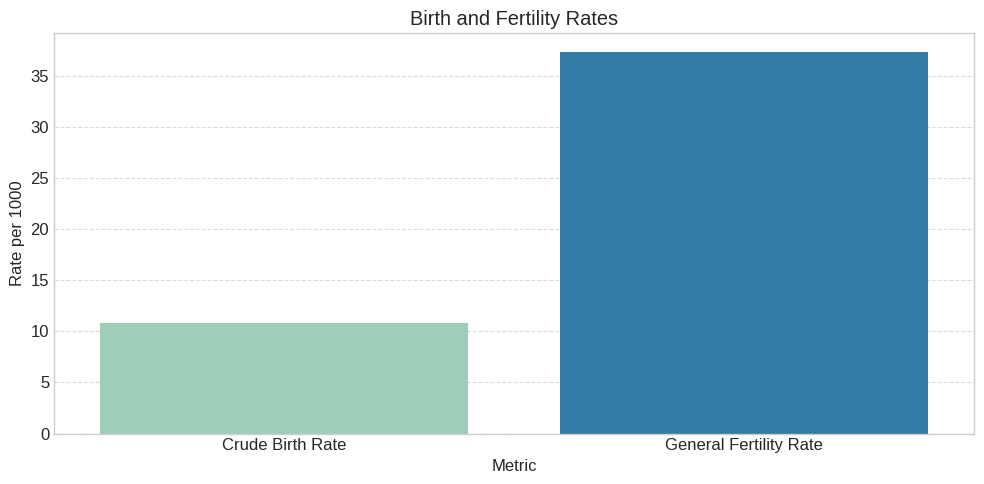

In [ ]:
fertility_data = {
    'Metric': ['Crude Birth Rate', 'General Fertility Rate'],
    'Value': [crude_birth_rate, fertility_rate]
}
fertility_df = pd.DataFrame(fertility_data)

plt.figure(figsize=(10, 5))
sns.barplot(x='Metric', y='Value', data=fertility_df, palette='YlGnBu')
plt.title('Birth and Fertility Rates')
plt.ylabel('Rate per 1000')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Mortality and Growth Metrics:
Estimated Annual Deaths: 58.9
Crude Death Rate: 6.17 per 1000 population
Natural Population Growth Rate: 4.64 per 1000 population
Natural Population Growth Rate: 0.46% per year


<ipython-input-40-e572ec31835f>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age Category', y='Mortality Rate', data=death_by_age, palette='RdPu')


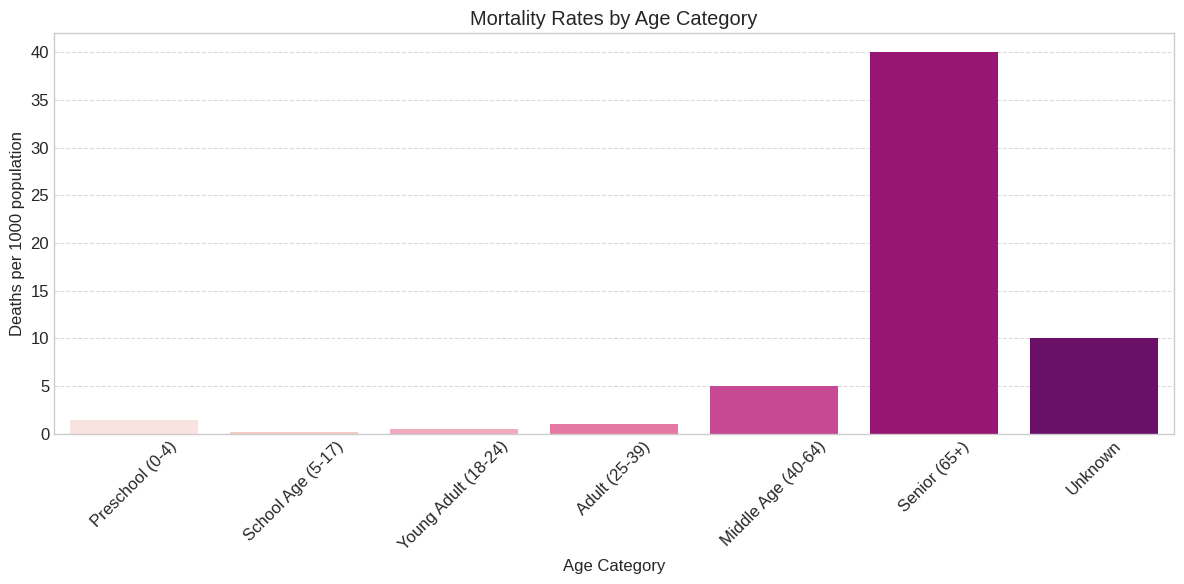

In [ ]:
mortality_rates = {
    'Preschool (0-4)': 1.5,
    'School Age (5-17)': 0.2,
    'Young Adult (18-24)': 0.5,
    'Adult (25-39)': 1.0,
    'Middle Age (40-64)': 5.0,
    'Senior (65+)': 40.0,
    'Unknown': 10.0
}

age_counts = clean_census['Age Category'].value_counts()
expected_deaths = sum(age_counts[age] * rate / 1000 for age, rate in mortality_rates.items())

crude_death_rate = (expected_deaths / total_population) * 1000

natural_growth_rate = crude_birth_rate - crude_death_rate

print("Mortality and Growth Metrics:")
print(f"Estimated Annual Deaths: {expected_deaths:.1f}")
print(f"Crude Death Rate: {crude_death_rate:.2f} per 1000 population")
print(f"Natural Population Growth Rate: {natural_growth_rate:.2f} per 1000 population")
print(f"Natural Population Growth Rate: {natural_growth_rate/10:.2f}% per year")

death_by_age = pd.DataFrame({
    'Age Category': list(mortality_rates.keys()),
    'Mortality Rate': list(mortality_rates.values())
})

plt.figure(figsize=(12, 6))
sns.barplot(x='Age Category', y='Mortality Rate', data=death_by_age, palette='RdPu')
plt.title('Mortality Rates by Age Category')
plt.ylabel('Deaths per 1000 population')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
years_projection = 10
annual_growth_rate = natural_growth_rate / 1000
projected_population = total_population * (1 + annual_growth_rate) ** years_projection

total_households = len(household_sizes)
additional_population = projected_population - total_population
additional_households_needed = additional_population / average_household_size

print("Projected Growth and Housing Needs:")
print(f"Current Population: {total_population}")
print(f"Projected Population in {years_projection} years: {projected_population:.0f}")
print(f"Population Increase: {additional_population:.0f} ({(additional_population/total_population*100):.2f}%)")
print(f"Additional Households Needed: {additional_households_needed:.0f}")

Projected Growth and Housing Needs:
Current Population: 9543
Projected Population in 10 years: 9995
Population Increase: 452 (4.74%)
Additional Households Needed: 158


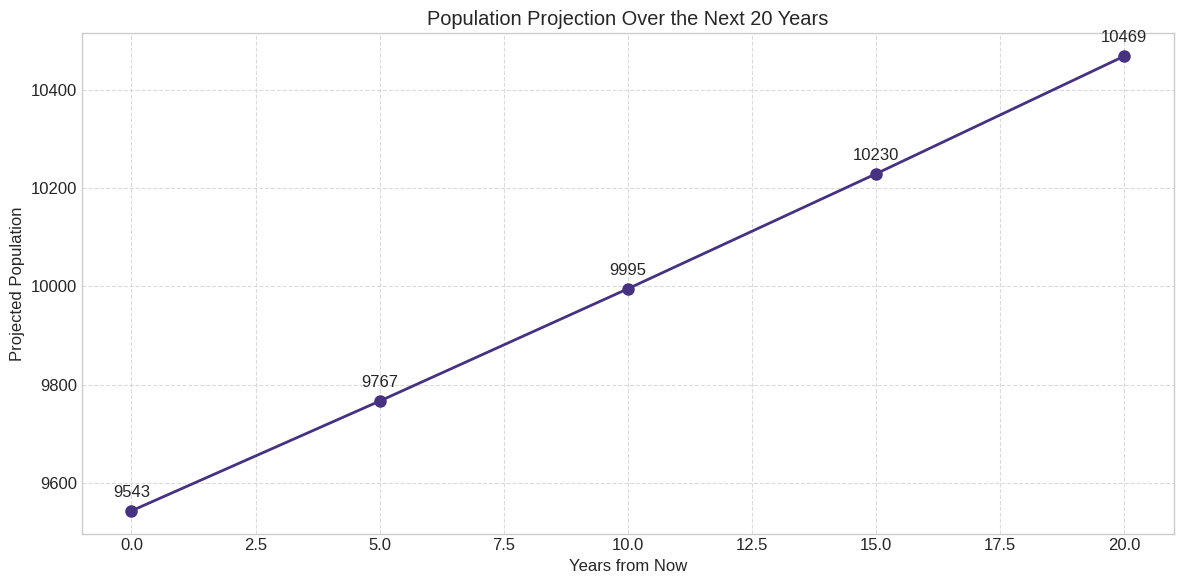

<Figure size 1400x800 with 0 Axes>

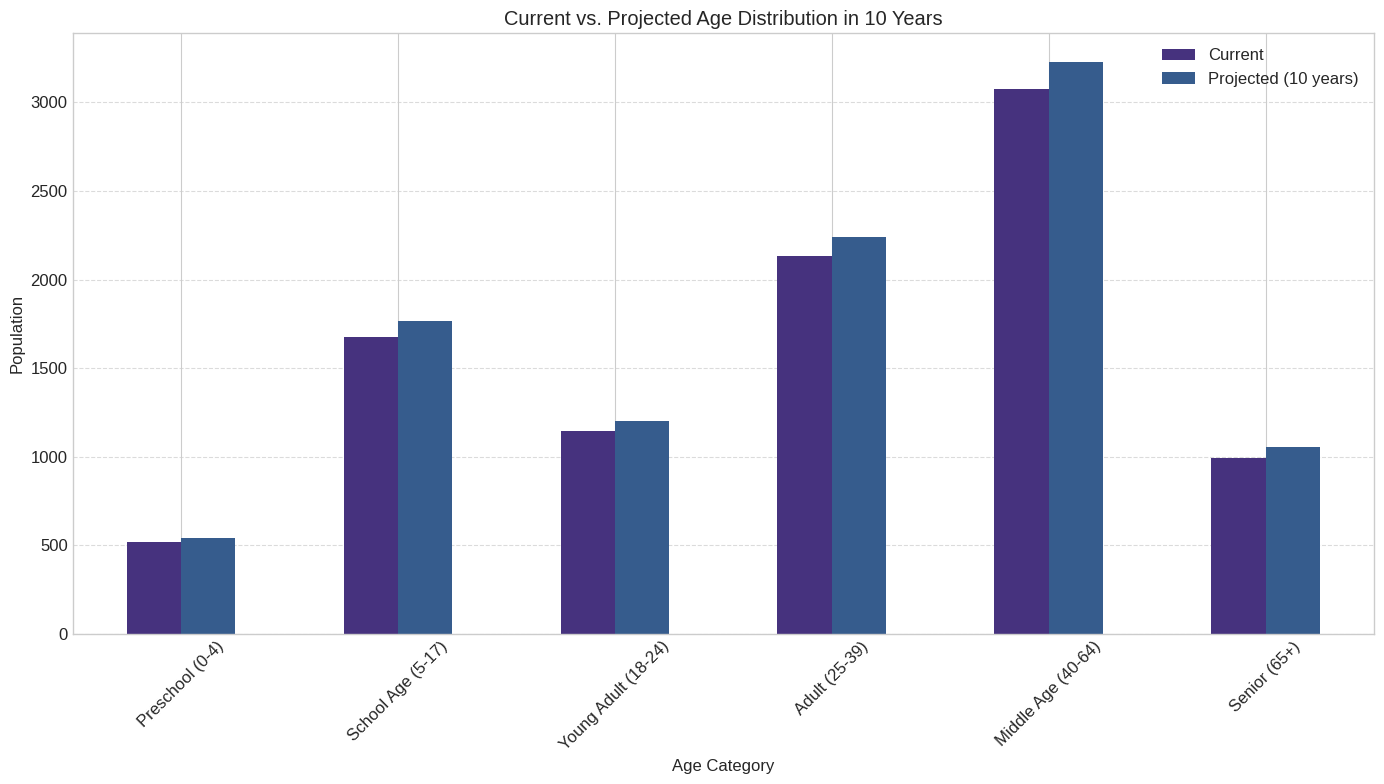

In [ ]:
projection_years = list(range(0, 21, 5))
projected_populations = [total_population * (1 + annual_growth_rate) ** year for year in projection_years]

plt.figure(figsize=(12, 6))
plt.plot(projection_years, projected_populations, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.title('Population Projection Over the Next 20 Years')
plt.xlabel('Years from Now')
plt.ylabel('Projected Population')
plt.grid(True, linestyle='--', alpha=0.7)

for i, pop in enumerate(projected_populations):
    plt.annotate(f"{pop:.0f}", (projection_years[i], pop), textcoords="offset points",
                 xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()

age_distribution_future = {}
for category in age_category_order:
    if category != 'Unknown':
        current = age_counts.get(category, 0)

        if 'Preschool' in category or 'School Age' in category:
            growth_multiplier = 1.1  # Higher for children due to birth rates
        elif 'Senior' in category:
            growth_multiplier = 1.3  # Higher for seniors due to aging population
        else:
            growth_multiplier = 1.05

        projected = current * (1 + annual_growth_rate * growth_multiplier) ** years_projection
        age_distribution_future[category] = projected

categories = list(age_distribution_future.keys())
current_values = [age_counts.get(cat, 0) for cat in categories]
future_values = list(age_distribution_future.values())

projection_data = pd.DataFrame({
    'Age Category': categories,
    'Current': current_values,
    'Future': future_values
})

plt.figure(figsize=(14, 8))
projection_data.set_index('Age Category').plot(kind='bar', figsize=(14, 8))
plt.title(f'Current vs. Projected Age Distribution in {years_projection} Years')
plt.ylabel('Population')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(['Current', f'Projected ({years_projection} years)'])
plt.tight_layout()
plt.show()

## 9. Decision Analysis: Land Use Options

In [ ]:
land_use_scores = {
    'High-Density Housing': 0,
    'Low-Density Housing': 0,
    'Train Station': 0,
    'Religious Building': 0,
    'Emergency Medical Building': 0
}

if natural_growth_rate > 5:
    land_use_scores['High-Density Housing'] += 3
elif natural_growth_rate > 0:
    land_use_scores['High-Density Housing'] += 2

overcrowded_households = household_sizes[household_sizes > 5].count()
overcrowding_rate = (overcrowded_households / total_households) * 100
if overcrowding_rate > 5:
    land_use_scores['High-Density Housing'] += 2

single_person_pct = household_type_pct.get('Single Person', 0)
if single_person_pct > 25:
    land_use_scores['High-Density Housing'] += 2

family_pct = household_type_pct.get('Married Couple with Children', 0) + household_type_pct.get('Single Parent Family', 0)
if family_pct > 30:
    land_use_scores['Low-Density Housing'] += 3

high_income_jobs = ['Banker', 'Investment banker', 'Doctor', 'Lawyer', 'Surgeon', 'Chief Financial Officer']
high_income_count = sum(clean_census['Occupation'].apply(
    lambda x: any(job.lower() in str(x).lower() for job in high_income_jobs) if not pd.isna(x) else False
))
high_income_pct = (high_income_count / len(adult_census)) * 100
if high_income_pct > 5:
    land_use_scores['Low-Density Housing'] += 2

commuter_pct = commuter_count / len(adult_census) * 100
if commuter_pct > 15:
    land_use_scores['Train Station'] += 4
elif commuter_pct > 10:
    land_use_scores['Train Station'] += 3
elif commuter_pct > 5:
    land_use_scores['Train Station'] += 2

uni_student_pct = len(uni_students) / len(adult_census) * 100
if uni_student_pct > 10:
    land_use_scores['Train Station'] += 2
elif uni_student_pct > 5:
    land_use_scores['Train Station'] += 1

catholic_count = religion_counts.get('Catholic', 0)
adherents_per_facility = catholic_count

major_religions = religion_counts[religion_counts > 20].drop(['Catholic', 'None', 'NA'], errors='ignore')
if not major_religions.empty:
    top_religion = major_religions.index[0]
    top_adherents = major_religions[0]

    if top_adherents > catholic_count * 0.75:
        land_use_scores['Religious Building'] += 3
    elif top_adherents > catholic_count * 0.5:
        land_use_scores['Religious Building'] += 2
    elif top_adherents > catholic_count * 0.25:
        land_use_scores['Religious Building'] += 1

vulnerable_pop = under_5_count + elderly_count
vulnerable_pct = (vulnerable_pop / total_population) * 100
if vulnerable_pct > 25:
    land_use_scores['Emergency Medical Building'] += 2
elif vulnerable_pct > 15:
    land_use_scores['Emergency Medical Building'] += 1

infirmity_pct = len(infirmities) / total_population * 100
if infirmity_pct > 5:
    land_use_scores['Emergency Medical Building'] += 2
elif infirmity_pct > 2:
    land_use_scores['Emergency Medical Building'] += 1

elderly_growth_rate = annual_growth_rate * 1.5
projected_elderly = elderly_count * (1 + elderly_growth_rate) ** years_projection
elderly_growth_pct = ((projected_elderly - elderly_count) / elderly_count) * 100
if elderly_growth_pct > 15:
    land_use_scores['Emergency Medical Building'] += 2
elif elderly_growth_pct > 10:
    land_use_scores['Emergency Medical Building'] += 1

print("Land Use Option Scores (higher is better):")
for option, score in sorted(land_use_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{option}: {score}/10")

recommended_land_use = max(land_use_scores.items(), key=lambda x: x[1])[0]
print(f"\nRecommended land use: {recommended_land_use}")

Land Use Option Scores (higher is better):
High-Density Housing: 6/10
Train Station: 4/10
Low-Density Housing: 3/10
Religious Building: 3/10
Emergency Medical Building: 3/10

Recommended land use: High-Density Housing


<ipython-input-43-9917d6a7834d>:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  top_adherents = major_religions[0]


## 10. Decision Analysis: Investment Priorities

In [ ]:
investment_scores = {
    'Employment and Training': 0,
    'Old Age Care': 0,
    'School Spending': 0,
    'General Infrastructure': 0
}

if unemployment_rate > 10:
    investment_scores['Employment and Training'] += 4
elif unemployment_rate > 7:
    investment_scores['Employment and Training'] += 3
elif unemployment_rate > 5:
    investment_scores['Employment and Training'] += 2

elderly_pct = (elderly_count / total_population) * 100
if elderly_pct > 20:
    investment_scores['Old Age Care'] += 3
elif elderly_pct > 15:
    investment_scores['Old Age Care'] += 2

if elderly_growth_pct > 20:
    investment_scores['Old Age Care'] += 3
elif elderly_growth_pct > 10:
    investment_scores['Old Age Care'] += 2

school_age_count = len(clean_census[clean_census['Age Category'] == 'School Age (5-17)'])
school_age_pct = (school_age_count / total_population) * 100
if school_age_pct > 20:
    investment_scores['School Spending'] += 2
elif school_age_pct > 15:
    investment_scores['School Spending'] += 1

preschool_count = len(clean_census[clean_census['Age Category'] == 'Preschool (0-4)'])
school_growth_potential = (preschool_count / school_age_count) * 100
if school_growth_potential > 30:
    investment_scores['School Spending'] += 3
elif school_growth_potential > 20:
    investment_scores['School Spending'] += 2

population_growth_pct = (additional_population / total_population) * 100
if population_growth_pct > 10:
    investment_scores['General Infrastructure'] += 3
elif population_growth_pct > 5:
    investment_scores['General Infrastructure'] += 2

if commuter_pct > 15:
    investment_scores['General Infrastructure'] += 2
elif commuter_pct > 10:
    investment_scores['General Infrastructure'] += 1

print("Investment Priority Scores (higher is better):")
for option, score in sorted(investment_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{option}: {score}/10")

recommended_investment = max(investment_scores.items(), key=lambda x: x[1])[0]
print(f"\nRecommended investment priority: {recommended_investment}")

Investment Priority Scores (higher is better):
School Spending: 4/10
Employment and Training: 3/10
General Infrastructure: 1/10
Old Age Care: 0/10

Recommended investment priority: School Spending


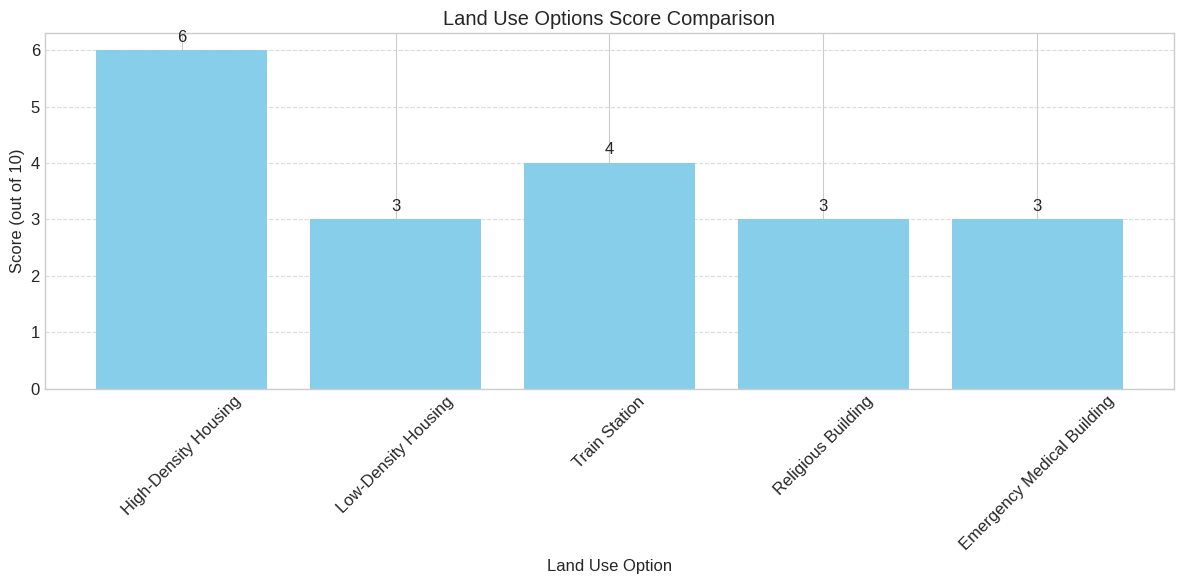

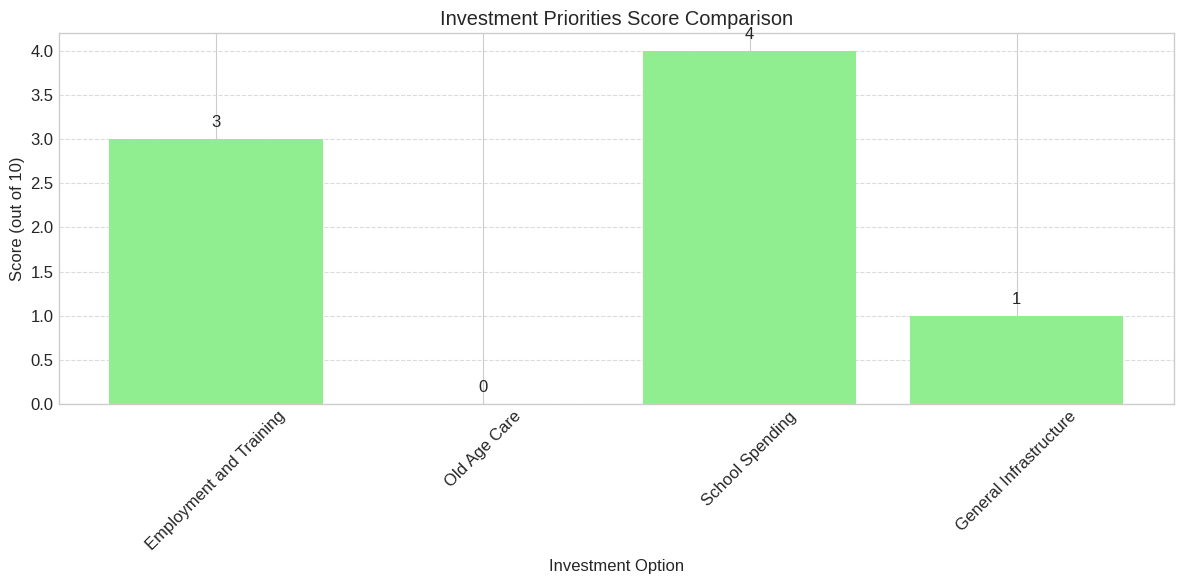

In [ ]:
land_use_options = list(land_use_scores.keys())
land_use_values = list(land_use_scores.values())

plt.figure(figsize=(12, 6))
bars = plt.bar(land_use_options, land_use_values, color='skyblue')
plt.title('Land Use Options Score Comparison')
plt.xlabel('Land Use Option')
plt.ylabel('Score (out of 10)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{height}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

investment_options = list(investment_scores.keys())
investment_values = list(investment_scores.values())

plt.figure(figsize=(12, 6))
bars = plt.bar(investment_options, investment_values, color='lightgreen')
plt.title('Investment Priorities Score Comparison')
plt.xlabel('Investment Option')
plt.ylabel('Score (out of 10)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{height}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()